# 🧠 Corrective RAG Summary

## Overview
**Corrective RAG (Retrieval-Augmented Generation)** enhances standard RAG by adding a *correction layer* that evaluates and filters retrieved documents before generation.

**Corrective RAG Concept**
* Add a corrector model that filters or re-ranks retrieved documents.
* Corrector ensures only relevant evidence is passed to the generator.

---

## 🔍 Key Idea
Traditional RAG retrieves documents and passes them directly to the generator.  
Corrective RAG introduces a **corrector model** that:
- Scores each document for relevance.
- Removes misleading or irrelevant evidence.
- Ensures the generator works with high-quality context.

---

## ⚙️ Workflow
1. **Query Input** → User asks a question.  
2. **Retriever** → Fetches candidate documents.  
3. **Corrector** → Filters or re-ranks documents.  
4. **Generator** → Produces the final answer using corrected context.  
5. **Feedback Loop** → System learns from mistakes to improve future retrieval.

---

## 💡 Benefits
- Reduces hallucinations.  
- Improves factual accuracy.  
- Increases trustworthiness of generated answers.

---

Step 1: Import libraries

In [21]:
# Step 1: Import necessary modules
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain.vectorstores import Chroma
from langchain.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List
from IPython.display import Image, display

Step 2: Create Document Data

In [2]:
# Sample Nigeria-related documents
documents = [
    'Nigeria gained independence from Britain in 1960.',
    'Lagos is the largest city and a major tech hub in Nigeria.',
    'The Nigerian Civil War lasted from 1967 to 1970.',
    'Nollywood is one of the largest film industries in the world.',
    'Nigeria is Africa’s biggest oil producer.',
    'The fintech sector in Nigeria is rapidly growing, with companies like Flutterwave and Paystack.',
    'Chinua Achebe wrote the famous novel Things Fall Apart.',
    'The Yoruba, Igbo, and Hausa-Fulani are the three largest ethnic groups in Nigeria.'
]

Step 3: Initialize Embeddings

In [3]:
embeddings = OpenAIEmbeddings()

Step 4: Build Chroma Vector Store

In [4]:
# Build Chroma vector store from documents
vector_store = Chroma.from_texts(
    documents,
    embeddings,
    collection_name='nigeria_docs'
)

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Step 5: Define Retriever

In [5]:
retriever = vector_store.as_retriever(search_kwargs= {'k': 3})

Part 2: Retriever and Corrector functions
* **Corrctor function** filters out irrelevant documents by checking keyword overlap with the query.

Step 6: Define State Schema

In [6]:
# Step 11: Define the state schema
class RAGState(TypedDict):
    '''
    RAGState defines the structure of data passed between nodes in the workflow.

    Attributes:
        query (str): The user's question or input.
        retrieved_docs (List[str]): Documents fetched from Chroma based on similarity search.
        corrected_docs (List[str]): Documents after filtering for relevance.
        answer (str): Final answer generated by the LLM.
    '''
    
    query: str                
    retrieved_docs: List[str]
    corrected_docs: List[str]
    answer: str
    
# Initialize a StateGraph with the schema
graph = StateGraph(RAGState)

Step 7: Initialize the LLM

In [7]:
def init_llm() -> ChatOpenAI:
    '''
    Initialize the OpenAI Chat LLM for use in the workflow.

    Returns:
        ChatOpenAI: Configured LLM instance ready for invocation.
    '''
    
    # Create llm    
    try:
        llm = ChatOpenAI(model_name='gpt-4o-mini', temperature=0)
        return llm
    
    except Exception as e:
        print(f'Error initializing LLM: {e}')
        return None
    
# Initialize once and reuse across nodes
llm = init_llm()

* **retrieval node:** This node fetches candidate documents from Chroma and stores them in the state.
* **correction node:** This node filters the retrieved documents using corrector function.
* **generation node:** This node uses the LLM to produce the final answer from corrected docs.

---

Step 8. **Retrieval Node**
* Pulls the query from the state.
* Uses the retriever (connected to Chroma) to fetch relevant documents.
* Saves the text content of those documents back into the state under retrieved_docs

In [8]:
# Step 13: Define the retrieval node
def retrieve_node(state: RAGState) -> RAGState:
    '''
    The retrieval node is responsible for fetching candidate documents
    from the Chroma vector store based on the user's query.

    Args:
        state (RAGState): The current workflow state containing the query.

    Returns:
        RAGState: Updated state with retrieved_docs populated.
    '''
    
    try:
        # Extract the user's query from the state
        query = state['query']
            
        # Use the retriever to fetch relevant documents from Chroma: similarity
        retrieved = retriever.get_relevant_documents(query)
            
        # Store only the text content of each document in the state
        state['retrieved_docs'] = [
            doc.page_content for doc in retrieved
        ]
    
    except Exception as e:
        state['retrieved_docs'] = []
        print(f'Error in retrieved_node: {e}')
    
    # Return the updated state so the next node can use it
    return state

Step 9. **Correction Node**

* Pulls the query and the retrieved documents from the state.
* Splits both into words and checks for overlap.
* Keeps only documents that share at least one keyword with the query.
* Saves those into corrected_docs in the state.

In [9]:
# Step 14: Define the correction node
def correct_node(state: RAGState) -> RAGState:
    '''
    The correction node filters the retrieved documents to remove irrelevant ones.
    It checks for keyword overlap between the user's query and each document.

    Args:
        state (RAGState): The current workflow state containing query and retrieved_docs.

    Returns:
        RAGState: Updated state with corrected_docs populated.
    '''
    
    try:
        # Extract the user's query from the state
        query = state['query']
            
        # Extract the list of retrieved documents (as plain text strings)
        docs = state['retrieved_docs']
            
        # Initialize an empty list to hold relevant documents
        corrected = []
            
        # Convert the query into a set of lowercase words
        query_words = set(query.lower().split())
            
        # Loop through each document
        for doc in docs:
            # Convert document text into a set of lowercase words
            doc_words = set(doc.lower().split())
                
            # Keep the document if it shares at least one keyword with the query
            if query_words & doc_words:
                corrected.append(doc)
                    
        # Store the filtered documents in the state
        state['corrected_docs'] = corrected
        
    except Exception as e:
        state['corrected_docs'] = []
        print(f'Error in correct_node: {e}')
        
    # Return the updated state so the next node can use it
    return state
        

**Step 10: Generation Node**

*Pulls the query and corrected documents from the state.
* Builds a prompt that tells the LLM to answer based only on those docs.
* Calls the LLM (llm.invoke) to generate the answer.
* Stores the answer back into the state under answer.

In [28]:
# Step 15: Define the generation node
def generate_node(state: RAGState) -> RAGState:
    '''
    The generation node uses the LLM (OpenAI GPT) to produce the final answer.
    It combines the corrected documents into a context string and asks the model
    to answer the user's query based on that context.

    It sends both a system instruction and a user query to the model.
    '''
    
    try:
        # Extract the user's query from the state
        query = state['query']
            
        # Extract the corrected documents 
        corrected_docs = state.get('corrected_docs', [])
            
        # Combine all corrected documents into one context string
        context = ' '.join(corrected_docs)
        
        # Define prompt template with system + user roles
        prompt = ChatPromptTemplate.from_messages([
            (
                'system',
                'You are a helpful assistant. '
                'Answer strictly based on the provided context. '
                'If the context does not contain enough information, reply: '
                "'I do not know based on the given context.'"
            ),
            (
                'user',
                'Context:\n{context}\n\n'
                'Question:\n{query}\n\n'
                'Answer:'
            )
        ])
        
        # Build chain: prompt → llm → parser
        chain = prompt | llm | StrOutputParser()
        
        # Invoke chain with variables
        answer = chain.invoke({
            'context': context,
            'query': query
        })
        
        # Save answer into state
        state['answer'] = answer
    
    except Exception as e:
        state['answer'] = f'Error in generate_node: {e}'
        
    return state

Step 11: Assemble the Workflow

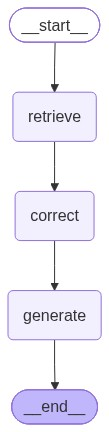

Graph rendered successfully


In [29]:
def assemble_workflow(graph: StateGraph) -> StateGraph:
    '''
    Assemble the Corrective RAG workflow by registering nodes and connecting them
    in the proper sequence: retrieve → correct → generate.

    Args:
        graph (StateGraph): The workflow graph initialized with RAGState schema.

    Returns:
        StateGraph: The fully assembled workflow graph.
    '''
    
    try:
        # Register node
        graph.add_node('retrieve', retrieve_node)
        graph.add_node('correct', correct_node)
        graph.add_node('generate', generate_node)
        
        # Connect nodes in sequence
        graph.add_edge(START, 'retrieve')
        graph.add_edge('retrieve', 'correct')
        graph.add_edge('correct', 'generate')
        graph.add_edge('generate', END)
        
        return graph
    
    except Exception as e:
        print(f'Error assembling workflow: {e}')
        return graph
    
# Assemble the workflow
graph = assemble_workflow(StateGraph(RAGState))

# Compile into runnable app
app = graph.compile()

try:
    display(Image(app.get_graph().draw_mermaid_png()))
    print('Graph rendered successfully')
except Exception as e:
    print(f'Error rendering graph: {e}')

Step 12: Executing the Workflow

In [31]:
# Run the workflow with a sample query
query = {
    'query': 'When did Nigeria gain independence?'
}

for step in app.stream(query):
    print(step)
    
result = app.invoke((query))
print(result)

C:\Users\USER\AppData\Local\Temp\ipykernel_14020\1848236387.py:19: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use invoke instead.
  retrieved = retriever.get_relevant_documents(query)
Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


{'retrieve': {'query': 'When did Nigeria gain independence?', 'retrieved_docs': ['Nigeria gained independence from Britain in 1960.', 'The Nigerian Civil War lasted from 1967 to 1970.', 'Nigeria is Africa’s biggest oil producer.'], 'corrected_docs': None, 'answer': None}}
{'correct': {'query': 'When did Nigeria gain independence?', 'retrieved_docs': ['Nigeria gained independence from Britain in 1960.', 'The Nigerian Civil War lasted from 1967 to 1970.', 'Nigeria is Africa’s biggest oil producer.'], 'corrected_docs': ['Nigeria gained independence from Britain in 1960.', 'Nigeria is Africa’s biggest oil producer.'], 'answer': None}}
{'generate': {'query': 'When did Nigeria gain independence?', 'retrieved_docs': ['Nigeria gained independence from Britain in 1960.', 'The Nigerian Civil War lasted from 1967 to 1970.', 'Nigeria is Africa’s biggest oil producer.'], 'corrected_docs': ['Nigeria gained independence from Britain in 1960.', 'Nigeria is Africa’s biggest oil producer.'], 'answer': '

In [32]:
result = app.invoke((query))
print(result)

{'query': 'When did Nigeria gain independence?', 'retrieved_docs': ['Nigeria gained independence from Britain in 1960.', 'The Nigerian Civil War lasted from 1967 to 1970.', 'Nigeria is Africa’s biggest oil producer.'], 'corrected_docs': ['Nigeria gained independence from Britain in 1960.', 'Nigeria is Africa’s biggest oil producer.'], 'answer': 'Nigeria gained independence in 1960.'}


In [35]:
query = {'query': 'When did Nigeria gain independence?'}

for update in app.stream(query, stream_mode='updates'):
    print('Update:', update)


Update: {'retrieve': {'query': 'When did Nigeria gain independence?', 'retrieved_docs': ['Nigeria gained independence from Britain in 1960.', 'The Nigerian Civil War lasted from 1967 to 1970.', 'Nigeria is Africa’s biggest oil producer.'], 'corrected_docs': None, 'answer': None}}
Update: {'correct': {'query': 'When did Nigeria gain independence?', 'retrieved_docs': ['Nigeria gained independence from Britain in 1960.', 'The Nigerian Civil War lasted from 1967 to 1970.', 'Nigeria is Africa’s biggest oil producer.'], 'corrected_docs': ['Nigeria gained independence from Britain in 1960.', 'Nigeria is Africa’s biggest oil producer.'], 'answer': None}}
Update: {'generate': {'query': 'When did Nigeria gain independence?', 'retrieved_docs': ['Nigeria gained independence from Britain in 1960.', 'The Nigerian Civil War lasted from 1967 to 1970.', 'Nigeria is Africa’s biggest oil producer.'], 'corrected_docs': ['Nigeria gained independence from Britain in 1960.', 'Nigeria is Africa’s biggest oil 

In [34]:
import json

query = {'query': 'When did Nigeria gain independence?'}

trace = []
for event in app.stream(query, stream_mode='values'):
    trace.append(event)

# Save trace to JSON file
with open('workflow_trace.json', 'w', encoding='utf-8') as f:
    json.dump(trace, f, indent=4, ensure_ascii=False)

print('Trace saved to workflow_trace.json')


Trace saved to workflow_trace.json
